## Abdalrahman Mohammed
abmm22@student.bth.se

### Question 1: Optimization Using Gradient Descent

Final x: 2.9963
Final y: -1.9975
Function value: 2e-05


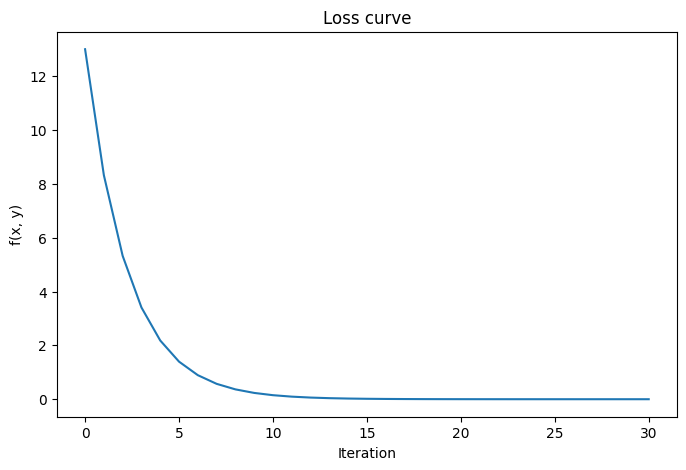

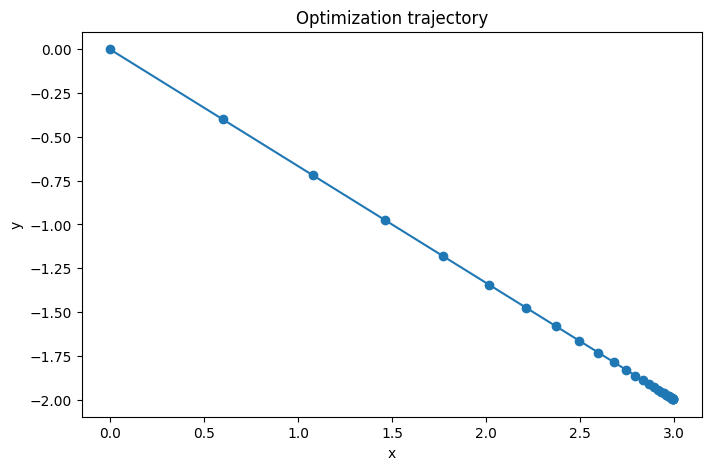

In [ ]:
import matplotlib.pyplot as plt

# parameters
learning_rate = 0.1
iterations = 30

# initial values
x, y = 0.0, 0.0

# store results
x_history = [x]
y_history = [y]
loss_history = [(x - 3)**2 + (y + 2)**2]

# gradient descent loop
for i in range(iterations):
    dfdx = 2 * (x - 3)
    dfdy = 2 * (y + 2)
    x = x - learning_rate * dfdx
    y = y - learning_rate * dfdy

    x_history.append(x)
    y_history.append(y)
    loss_history.append((x - 3)**2 + (y + 2)**2)

# final result
print("Final x:", round(x, 4))
print("Final y:", round(y, 4))
print("Function value:", round((x - 3)**2 + (y + 2)**2, 6))

# plot loss curve
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Loss curve")
plt.xlabel("Iteration")
plt.ylabel("f(x, y)")
plt.show()

# plot optimization trajectory
plt.figure(figsize=(8, 5))
plt.plot(x_history, y_history, marker='o')
plt.title("Optimization trajectory")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Question 2: Deep Learning for Image Classification

##### Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.models import (resnet50, vgg19, densenet121, efficientnet_b0, ResNet50_Weights, VGG19_Weights, DenseNet121_Weights, EfficientNet_B0_Weights)
import gc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, multilabel_confusion_matrix
import copy

##### GPU Check

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using:", device)

torch.backends.cudnn.benchmark = True # makes cuda faster

Using: cuda


##### Training Setup

In [ ]:
num_classes = 100
batch_size = 128
epochs = 50
num_workers = 4

mixed_precision  = torch.cuda.is_available() # enable faster gpu training

##### Data Preparation

In [ ]:
# image transformations
transform_train = transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(), transforms.ToTensor(), transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])
transform_eval = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))])

# load cifar100 datasets
train_data  = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform_train)
val_data  = torchvision.datasets.CIFAR100(root="./data", train=True, download=True, transform=transform_eval)
test_data = torchvision.datasets.CIFAR100(root="./data", train=False, download=True, transform=transform_eval)

train_size = int(0.9 * len(train_data ))
val_size = len(train_data ) - train_size

seed = torch.Generator().manual_seed(69)

train_split, val_split  = random_split(train_data , [train_size, val_size], generator=seed)

train_set = train_split.indices
val_set = val_split .indices

# final train and validation sets
train_set = Subset(train_data , train_set )
val_set = Subset(val_data , val_set )

# data loaders
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

c:\Users\mucko\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


##### Models

In [ ]:
class CNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()

        # feature extractor
        self.features = nn.Sequential(
            # layer 1
            nn.Conv2d(3, 32, 3, padding=1),     # 3 input channels to 32 output channels
            nn.BatchNorm2d(32),                 # normalize outputs
            nn.ReLU(),                          # keep positive values

            # layer 2
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                    # 224px to 112px

            # layer 3
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            # layer 4
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                    # 112px to 56px

            # layer 5
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            # layer 6
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),                    # 56px to 28px 

            # layer 7
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),

            # layer 8
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),                     # 28px to 14px

            nn.AdaptiveAvgPool2d((1, 1))         # make each channel 1x1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.5),                    # drop half during training
            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        images = self.features(images)
        images = self.classifier(images)
        return images


def run_CNN():
    return CNN(num_classes=num_classes)


def run_resnet50():
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def run_vgg19():
    model = vgg19(weights=VGG19_Weights.DEFAULT)
    model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)
    return model


def run_densenet121():
    model = densenet121(weights=DenseNet121_Weights.DEFAULT)
    model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    return model


def run_efficientnet_b0():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

##### Train and Evaluate

In [ ]:
def train_one_epoch(model, loader, loss_fn, optimizer, scaler):
    model.train()

    loss_sum = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True) 
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)  # clear old gradients

        # model prediction and loss calculation
        with torch.amp.autocast("cuda", enabled=mixed_precision):
            outputs = model(images)
            loss = loss_fn(outputs, labels)

        # update model weights
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # save loss and accuracy info
        loss_sum += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = loss_sum / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy


@torch.no_grad()


def evaluate(model, loader, loss_fn):
    model.eval()

    loss_sum = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # model prediction and loss calculation
        with torch.amp.autocast("cuda", enabled=mixed_precision):
            outputs = model(images)
            loss = loss_fn(outputs, labels)

        # save loss and accuracy info
        loss_sum += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = loss_sum / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

##### Helper Functions

In [ ]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_val_loss = float("inf")
        self.count = 0
        self.best_weights = None
        self.stop = False

    def check(self, val_loss, model):
        # save model if validation loss improves
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.count = 0
            self.best_weights = copy.deepcopy(model.state_dict())
            
        # count epochs without improvement
        else:
            self.count += 1
            if self.count >= self.patience:
                self.stop = True


def plot_results(history, model_name):
    epochs  = range(1, len(history["train_loss"]) + 1)

    # plot loss
    plt.figure(figsize=(6, 4))
    plt.plot(epochs , history["train_loss"], label="Train loss")
    plt.plot(epochs , history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_name} Loss")
    plt.legend()
    plt.show()

    # plot accuracy
    plt.figure(figsize=(6, 4))
    plt.plot(epochs , history["train_acc"], label="Train acc")
    plt.plot(epochs , history["val_acc"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_name} Accuracy")
    plt.legend()
    plt.show()


def get__conv_weights(model):
    for layer in model.modules():
        if isinstance(layer, nn.Conv2d):
            return layer.weight.detach().cpu().clone()
    return None


def plot_filters(before, after, model_name, num_filters=2):
    fig, axes = plt.subplots(num_filters, 2, figsize=(6, 3 * num_filters))

    for i in range(num_filters):
        old_filter  = before[i].mean(dim=0).numpy()
        new_filter  = after[i].mean(dim=0).numpy()

        axes[i, 0].imshow(old_filter , cmap="gray")
        axes[i, 0].set_title(f"{model_name} filter {i+1} before")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(new_filter , cmap="gray")
        axes[i, 1].set_title(f"{model_name} filter {i+1} after")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()
    
    
@torch.no_grad()


def get_metrics(model, loader):
    model.eval()

    all_labels = []
    all_preds = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        # store labels and predictions
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    acc = (all_preds == all_labels).mean()
    f1 = f1_score(all_labels, all_preds, average="macro")

    # confusion matrix for each class
    mcm = multilabel_confusion_matrix(all_labels, all_preds, labels=np.arange(num_classes))

    tn = mcm[:, 0, 0].mean()
    fp = mcm[:, 0, 1].mean()
    fn = mcm[:, 1, 0].mean()
    tp = mcm[:, 1, 1].mean()

    return acc, tp, tn, fp, fn, f1

##### Run and Compare Models


Running model: CNN

Epoch 1/50 | Train Loss: 4.0764, Train Acc: 0.0695 | Val Loss: 3.8575, Val Acc: 0.0956
Epoch 2/50 | Train Loss: 3.7597, Train Acc: 0.1100 | Val Loss: 3.7178, Val Acc: 0.1170
Epoch 3/50 | Train Loss: 3.6128, Train Acc: 0.1332 | Val Loss: 3.5009, Val Acc: 0.1606
Epoch 4/50 | Train Loss: 3.4884, Train Acc: 0.1549 | Val Loss: 3.4067, Val Acc: 0.1738
Epoch 5/50 | Train Loss: 3.3326, Train Acc: 0.1838 | Val Loss: 3.1934, Val Acc: 0.2162
Epoch 6/50 | Train Loss: 3.1412, Train Acc: 0.2140 | Val Loss: 3.0652, Val Acc: 0.2342
Epoch 7/50 | Train Loss: 2.9932, Train Acc: 0.2444 | Val Loss: 2.8515, Val Acc: 0.2690
Epoch 8/50 | Train Loss: 2.8681, Train Acc: 0.2658 | Val Loss: 2.7784, Val Acc: 0.2900
Epoch 9/50 | Train Loss: 2.7621, Train Acc: 0.2868 | Val Loss: 2.6934, Val Acc: 0.3074
Epoch 10/50 | Train Loss: 2.6630, Train Acc: 0.3047 | Val Loss: 2.6084, Val Acc: 0.3252
Epoch 11/50 | Train Loss: 2.5740, Train Acc: 0.3259 | Val Loss: 2.5335, Val Acc: 0.3382
Epoch 12/50 | Train 

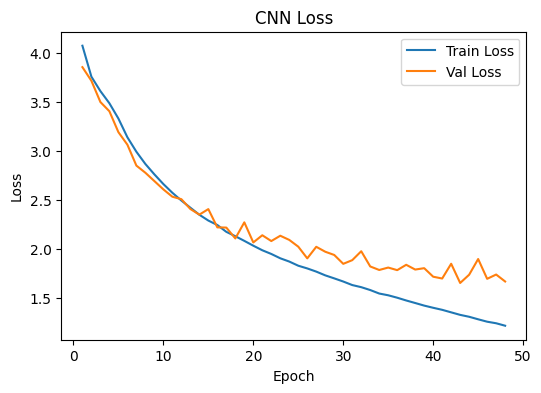

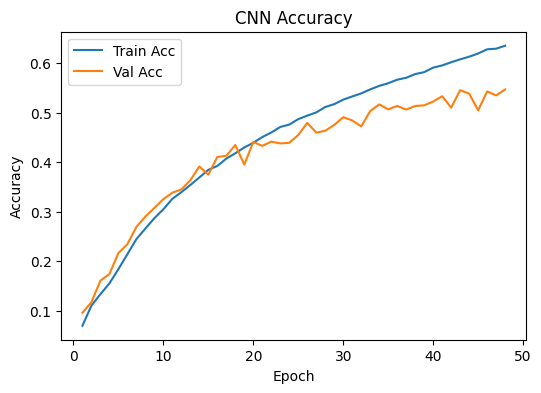

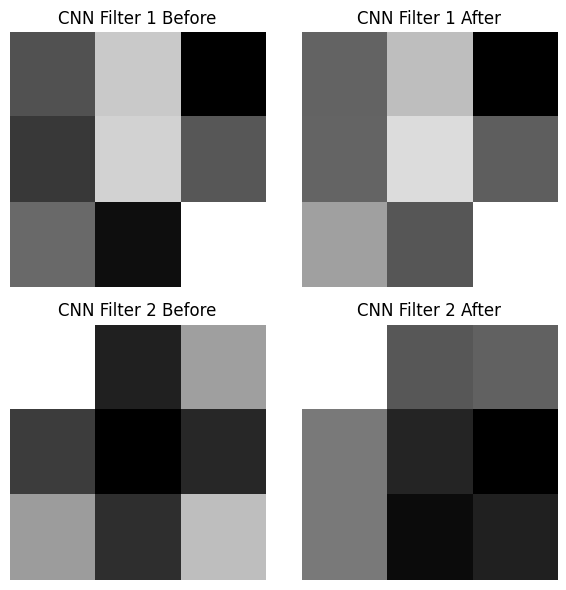


Running model: ResNet50

Epoch 1/50 | Train Loss: 1.6364, Train Acc: 0.5481 | Val Loss: 1.2270, Val Acc: 0.6474
Epoch 2/50 | Train Loss: 0.8874, Train Acc: 0.7344 | Val Loss: 1.0884, Val Acc: 0.6820
Epoch 3/50 | Train Loss: 0.6369, Train Acc: 0.8043 | Val Loss: 1.0083, Val Acc: 0.7134
Epoch 4/50 | Train Loss: 0.4715, Train Acc: 0.8521 | Val Loss: 1.0268, Val Acc: 0.7110
Epoch 5/50 | Train Loss: 0.3524, Train Acc: 0.8872 | Val Loss: 0.9301, Val Acc: 0.7482
Epoch 6/50 | Train Loss: 0.2641, Train Acc: 0.9146 | Val Loss: 0.9512, Val Acc: 0.7432
Epoch 7/50 | Train Loss: 0.1994, Train Acc: 0.9362 | Val Loss: 1.0407, Val Acc: 0.7380
Epoch 8/50 | Train Loss: 0.1802, Train Acc: 0.9423 | Val Loss: 1.0118, Val Acc: 0.7522
Epoch 9/50 | Train Loss: 0.1466, Train Acc: 0.9535 | Val Loss: 1.0480, Val Acc: 0.7462
Epoch 10/50 | Train Loss: 0.1275, Train Acc: 0.9597 | Val Loss: 1.0311, Val Acc: 0.7472
Early stopping

Test Loss: 0.9175, Test Acc: 0.7413



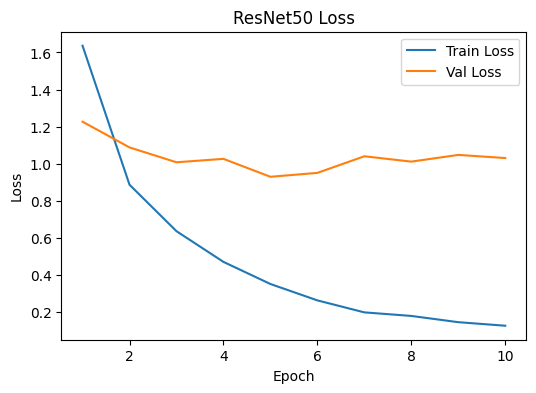

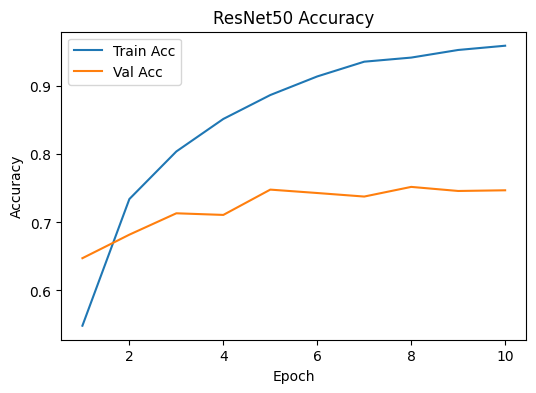


Running model: VGG19

Epoch 1/50 | Train Loss: 4.4455, Train Acc: 0.0259 | Val Loss: 4.0971, Val Acc: 0.0528
Epoch 2/50 | Train Loss: 3.9213, Train Acc: 0.0824 | Val Loss: 3.6902, Val Acc: 0.1216
Epoch 3/50 | Train Loss: 3.6109, Train Acc: 0.1356 | Val Loss: 3.4322, Val Acc: 0.1638
Epoch 4/50 | Train Loss: 3.3828, Train Acc: 0.1771 | Val Loss: 3.2406, Val Acc: 0.2042
Epoch 5/50 | Train Loss: 3.1819, Train Acc: 0.2160 | Val Loss: 3.1358, Val Acc: 0.2250
Epoch 6/50 | Train Loss: 3.0198, Train Acc: 0.2466 | Val Loss: 2.9137, Val Acc: 0.2632
Epoch 7/50 | Train Loss: 2.8733, Train Acc: 0.2726 | Val Loss: 2.8346, Val Acc: 0.2830
Epoch 8/50 | Train Loss: 2.7281, Train Acc: 0.3028 | Val Loss: 2.7001, Val Acc: 0.3120
Epoch 9/50 | Train Loss: 2.6062, Train Acc: 0.3280 | Val Loss: 2.5997, Val Acc: 0.3368
Epoch 10/50 | Train Loss: 2.4996, Train Acc: 0.3498 | Val Loss: 2.5150, Val Acc: 0.3556
Epoch 11/50 | Train Loss: 2.4032, Train Acc: 0.3747 | Val Loss: 2.5472, Val Acc: 0.3484
Epoch 12/50 | Trai

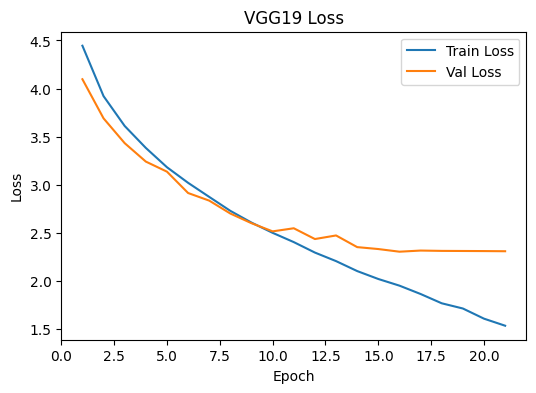

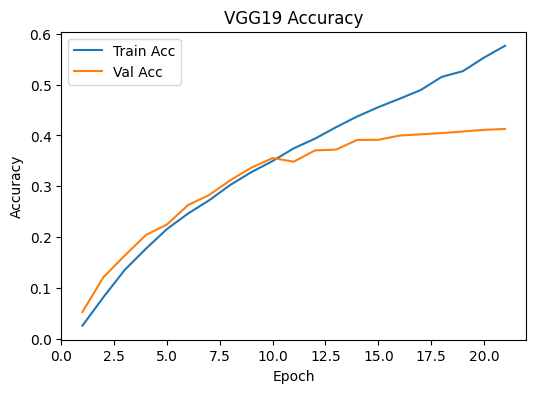


Running model: DenseNet121

Epoch 1/50 | Train Loss: 1.7044, Train Acc: 0.5324 | Val Loss: 1.2777, Val Acc: 0.6302
Epoch 2/50 | Train Loss: 0.9844, Train Acc: 0.7073 | Val Loss: 1.0470, Val Acc: 0.7008
Epoch 3/50 | Train Loss: 0.7564, Train Acc: 0.7669 | Val Loss: 1.0303, Val Acc: 0.6994
Epoch 4/50 | Train Loss: 0.6032, Train Acc: 0.8128 | Val Loss: 0.8918, Val Acc: 0.7422
Epoch 5/50 | Train Loss: 0.4865, Train Acc: 0.8464 | Val Loss: 1.0424, Val Acc: 0.7172
Epoch 6/50 | Train Loss: 0.4067, Train Acc: 0.8695 | Val Loss: 0.9300, Val Acc: 0.7460
Epoch 7/50 | Train Loss: 0.3246, Train Acc: 0.8953 | Val Loss: 0.9283, Val Acc: 0.7438
Epoch 8/50 | Train Loss: 0.2700, Train Acc: 0.9104 | Val Loss: 0.9482, Val Acc: 0.7578
Epoch 9/50 | Train Loss: 0.2414, Train Acc: 0.9210 | Val Loss: 1.0428, Val Acc: 0.7338
Early stopping

Test Loss: 0.8958, Test Acc: 0.7403



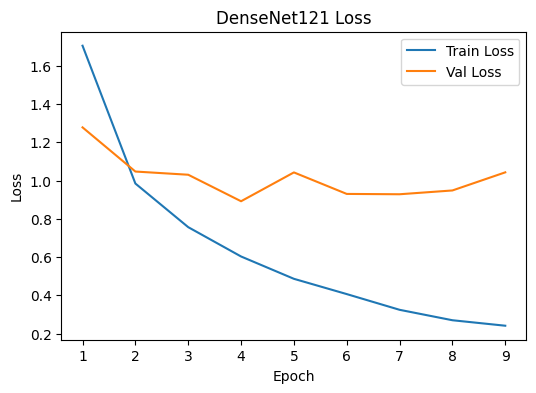

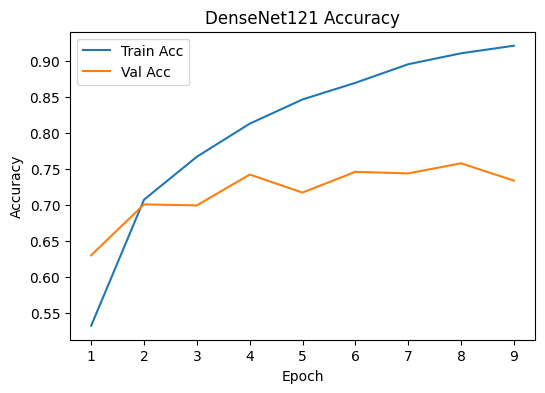


Running model: EfficientNetB0

Epoch 1/50 | Train Loss: 1.3621, Train Acc: 0.6285 | Val Loss: 0.8628, Val Acc: 0.7468
Epoch 2/50 | Train Loss: 0.7038, Train Acc: 0.7865 | Val Loss: 0.7810, Val Acc: 0.7678
Epoch 3/50 | Train Loss: 0.5175, Train Acc: 0.8381 | Val Loss: 0.7900, Val Acc: 0.7768
Epoch 4/50 | Train Loss: 0.4008, Train Acc: 0.8718 | Val Loss: 0.7896, Val Acc: 0.7896
Epoch 5/50 | Train Loss: 0.3276, Train Acc: 0.8937 | Val Loss: 0.7843, Val Acc: 0.7896
Epoch 6/50 | Train Loss: 0.2774, Train Acc: 0.9095 | Val Loss: 0.8188, Val Acc: 0.7868
Epoch 7/50 | Train Loss: 0.2330, Train Acc: 0.9231 | Val Loss: 0.8391, Val Acc: 0.7908
Early stopping

Test Loss: 0.7983, Test Acc: 0.7637



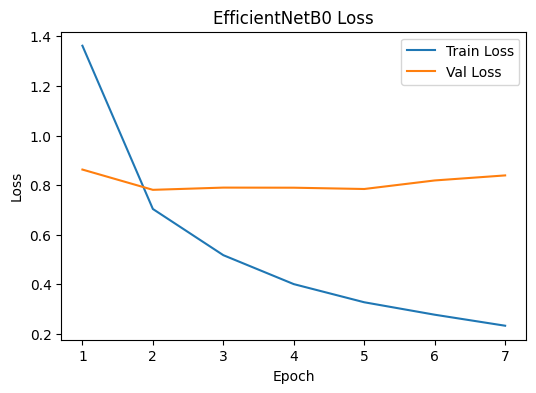

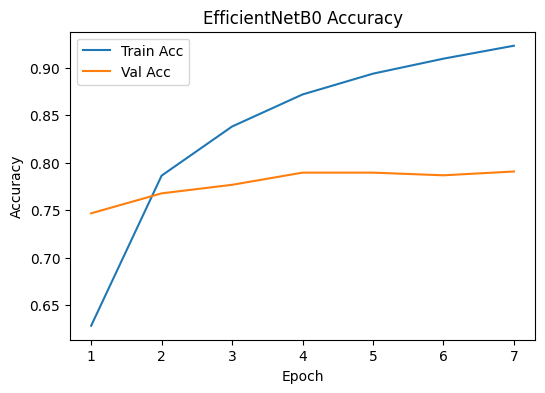


Final results
            Model  Accuracy     TP       TN     FP     FN  F1-score
0             CNN    0.5558  55.58  9855.58  44.42  44.42  0.554333
1        ResNet50    0.7409  74.09  9874.09  25.91  25.91  0.738865
2           VGG19    0.4103  41.03  9841.03  58.97  58.97  0.406964
3     DenseNet121    0.7403  74.03  9874.03  25.97  25.97  0.740967
4  EfficientNetB0    0.7633  76.33  9876.33  23.67  23.67  0.760493


In [ ]:
def run_model(model_name, build_model):
    print(f"\nRunning model: {model_name}\n")

    model = build_model().to(device)

    # set loss function, optimizer, scaler and early stopping
    loss_fn = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scaler = torch.amp.GradScaler("cuda", enabled=mixed_precision)
    early_stopping = EarlyStopping(patience=5)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # save first layer before training for custom cnn
    first_before = None
    if model_name == "CNN":
        first_before = get__conv_weights(model)

    # train model for each epoch
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, scaler)
        val_loss, val_acc = evaluate(model, val_loader, loss_fn)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch + 1}/{epochs} | Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}", flush=True)

        early_stopping.check(val_loss, model)
        if early_stopping.stop:
            print("Early stopping")
            break

    # load best model
    if early_stopping.best_weights is not None:
        model.load_state_dict(early_stopping.best_weights)

    test_loss, test_acc = evaluate(model, test_loader, loss_fn)

    print(f"\nTest loss: {test_loss:.4f}, Test acc: {test_acc:.4f}\n")

    plot_results(history, model_name)

    # show filters before and after for custom CNN
    if model_name == "CNN":
        first_after = get__conv_weights(model)
        plot_filters(first_before, first_after, model_name)

    acc, tp, tn, fp, fn, f1 = get_metrics(model, test_loader)

    # clear memory
    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {"Model": model_name, "Accuracy": acc, "TP": tp, "TN": tn, "FP": fp, "FN": fn, "F1-score": f1}


results = []

models = [("CNN", run_CNN), ("ResNet50", run_resnet50), ("VGG19", run_vgg19), ("DenseNet121", run_densenet121), ("EfficientNetB0", run_efficientnet_b0)]

for model_name, build_model in models:
    results.append(run_model(model_name, build_model))

results_table = pd.DataFrame(results)

print("\nFinal results")
print(results_table)